In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive


'Adsız klasör'	 archive3.zip   archive.zip  'Colab Notebooks'	 madrid_data


In [3]:
!unzip "/content/drive/MyDrive/archive.zip" -d /content/butterfly_dataset


Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: /content/butterfly_dataset/train/Image_2348.jpg  
  inflating: /content/butterfly_dataset/train/Image_2349.jpg  
  inflating: /content/butterfly_dataset/train/Image_235.jpg  
  inflating: /content/butterfly_dataset/train/Image_2350.jpg  
  inflating: /content/butterfly_dataset/train/Image_2351.jpg  
  inflating: /content/butterfly_dataset/train/Image_2352.jpg  
  inflating: /content/butterfly_dataset/train/Image_2353.jpg  
  inflating: /content/butterfly_dataset/train/Image_2354.jpg  
  inflating: /content/butterfly_dataset/train/Image_2355.jpg  
  inflating: /content/butterfly_dataset/train/Image_2356.jpg  
  inflating: /content/butterfly_dataset/train/Image_2357.jpg  
  inflating: /content/butterfly_dataset/train/Image_2358.jpg  
  inflating: /content/butterfly_dataset/train/Image_2359.jpg  
  inflating: /content/butterfly_dataset/train/Image_236.jpg  
  inflating: /content/butterfly_dataset/train/Image_2360.jpg  
  inflatin

In [4]:
!ls /content/butterfly_dataset


test  Testing_set.csv  train  Training_set.csv


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [6]:
!cd /content && zip -r -q butterfly_dataset.zip butterfly_dataset
!ls -lah /content/butterfly_dataset.zip


-rw-r--r-- 1 root root 227M Jan  1 22:46 /content/butterfly_dataset.zip


In [39]:
import numpy as np
import torch
import torch.nn as nn

trained_models = {}

@torch.no_grad()
def predict_torch(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    for xb, yb in dataloader:
        xb = xb.to(device)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        y_pred.append(pred)
        y_true.append(yb.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


In [43]:
# Paths
DATA_DIR = "/content/butterfly_dataset"
OUTPUT_DIR = "/content/outputs"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Imports
import time, copy, random, itertools
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.transforms import InterpolationMode
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Hyperparams
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
PATIENCE = 3
BASE_LR = 1e-4
WEIGHT_DECAY = 1e-4
SPLIT = (0.70, 0.10, 0.20)  # train/val/test (train klasörünün içinden)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False


set_seed(SEED)


Device: cuda


In [8]:
class PathDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples  # [(path, label), ...]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, target


In [9]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.1),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ColorJitter(0.2, 0.2, 0.15, 0.05),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.2), ratio=(0.3,3.3))
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.14), interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])


In [10]:
import pandas as pd

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train")
train_csv = os.path.join(DATA_DIR, "Training_set.csv")
df = pd.read_csv(train_csv)

print("Training CSV columns:", list(df.columns))
print(df.head())

# CSV kolonları (çoğu dataset için böyle)
fname_col = "filename"

# label kolonu csv’de "label" değilse burada değiştir (ör: "species")
label_col = "label" if "label" in df.columns else df.columns[1]

# class names ve mapping
class_names = sorted(df[label_col].unique().tolist())
num_classes = len(class_names)
class_to_idx = {c:i for i,c in enumerate(class_names)}

# paths ve labels
paths = [os.path.join(TRAIN_IMG_DIR, fn) for fn in df[fname_col].astype(str).tolist()]
labels = np.array([class_to_idx[x] for x in df[label_col].tolist()], dtype=np.int64)

# güvenlik kontrolü
if not os.path.isdir(TRAIN_IMG_DIR):
    raise FileNotFoundError(TRAIN_IMG_DIR)
if not os.path.exists(paths[0]):
    raise FileNotFoundError(f"Örnek dosya bulunamadı: {paths[0]}")

# Stratified split
train_r, val_r, test_r = SPLIT

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=(1.0 - train_r), random_state=SEED)
train_idx, temp_idx = next(sss1.split(paths, labels))

temp_labels = labels[temp_idx]
val_size = val_r / (val_r + test_r)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=(1.0 - val_size), random_state=SEED)
val_rel, test_rel = next(sss2.split(temp_idx, temp_labels))

val_idx = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

train_samples = [(paths[i], int(labels[i])) for i in train_idx]
val_samples   = [(paths[i], int(labels[i])) for i in val_idx]
test_samples  = [(paths[i], int(labels[i])) for i in test_idx]

print(f"Toplam: {len(paths)} | Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")
print("Sınıf sayısı:", num_classes)
print("Örnek sınıflar:", class_names[:10])


Training CSV columns: ['filename', 'label']
      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART
Toplam: 6499 | Train: 4549 | Val: 649 | Test: 1301
Sınıf sayısı: 75
Örnek sınıflar: ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK']


In [44]:
train_ds = PathDataset(train_samples, transform=train_tf)
val_ds   = PathDataset(val_samples,   transform=eval_tf)
test_ds  = PathDataset(test_samples,  transform=eval_tf)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# hızlı sanity check
xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape)


Batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


In [12]:
amp_dtype = torch.float16 if device.type == "cuda" else torch.float32


In [38]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

def train_one_model(model_name):
    set_seed(SEED)

    model = make_model(model_name, num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

    use_amp = (device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    amp_dtype = torch.float16 if device.type == "cuda" else torch.float32

    best_val_acc = 0.0
    best_state = None
    no_improve = 0
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    print(f"\n=== Training {model_name} ===")
    for epoch in range(1, EPOCHS+1):
        t0 = time.time()

        # --- Train ---
        model.train()
        run_loss, run_correct, run_total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                out = model(xb)
                loss = criterion(out, yb)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            preds = out.argmax(1)
            run_loss += loss.item() * xb.size(0)
            run_correct += (preds == yb).sum().item()
            run_total += xb.size(0)

        train_loss = run_loss / run_total
        train_acc  = run_correct / run_total

        # --- Val ---
        model.eval()
        v_loss, v_cor, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                    out = model(xb)
                    loss = criterion(out, yb)

                v_loss += loss.item() * xb.size(0)
                v_cor  += (out.argmax(1) == yb).sum().item()
                v_tot  += xb.size(0)

        val_loss = v_loss / v_tot
        val_acc  = v_cor / v_tot

        scheduler.step(epoch + val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"train {train_loss:.4f}/{train_acc:.4f} | "
              f"val {val_loss:.4f}/{val_acc:.4f} | "
              f"{time.time()-t0:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(OUTPUT_DIR, f"best_{model_name}.pth"))
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # --- Test (bizim split test) ---
    model.eval()
    all_preds, all_tgts = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                out = model(xb)
            all_preds.append(out.argmax(1).cpu().numpy())
            all_tgts.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_tgts)
    test_acc = accuracy_score(y_true, y_pred)

    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    cm = confusion_matrix(y_true, y_pred)

    # Curves plot
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="train")
    plt.plot(history["val_acc"], label="val")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{model_name}_curves.png"), dpi=150)
    plt.show()

    # Confusion matrix plot (çok sınıfta kalabalık olabilir)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(6,5))
    plt.imshow(cmn, interpolation="nearest")
    plt.title(f"{model_name} - Confusion Matrix (Normalized)")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.ylabel("Gerçek"); plt.xlabel("Tahmin")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{model_name}_cm.png"), dpi=150)
    plt.show()

    with open(os.path.join(OUTPUT_DIR, f"{model_name}_report.txt"), "w") as f:
        f.write(report + f"\nTest Acc: {test_acc:.4f}\nBest Val Acc: {best_val_acc:.4f}\n")

    print("\n=== Test Report ===")
    print(report)
    print(f"Test Acc: {test_acc:.4f} | Best Val Acc: {best_val_acc:.4f}")

    return {
    "name": model_name,
    "history": history,
    "best_val_acc": best_val_acc,
    "test_acc": test_acc,
    "model": model
}




In [14]:
MODEL_NAMES = [
    "resnet50",
    "densenet121",
    "convnext_tiny",
    "swin_t"
]


In [15]:
from torchvision import models
import torch.nn as nn

def make_model(name, num_classes):
    name = name.lower()

    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)

    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)

    elif name == "mobilenet_v3_large":
        m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)

    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)

    elif name == "vit_b_16":
        m = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        m.heads.head = nn.Linear(m.heads.head.in_features, num_classes)

    elif name == "convnext_tiny":
        m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)

    elif name == "swin_t":
        m = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
        m.head = nn.Linear(m.head.in_features, num_classes)

    else:
        raise ValueError(f"Unknown model: {name}")

    return m


In [16]:
MODEL_NAMES = ["resnet50", "densenet121", "convnext_tiny", "swin_t"]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 127MB/s]
/tmp/ipython-input-3123343829.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)



=== Training resnet50 ===
Epoch 01/5 | train 3.2209/0.3691 | val 1.2041/0.7951 | 63.8s
Epoch 02/5 | train 1.2356/0.7978 | val 0.8298/0.9060 | 44.1s
Epoch 03/5 | train 0.9126/0.8776 | val 0.7497/0.9276 | 44.7s
Epoch 04/5 | train 0.8201/0.9011 | val 0.7188/0.9384 | 44.7s
Epoch 05/5 | train 0.7787/0.9116 | val 0.7210/0.9445 | 43.4s


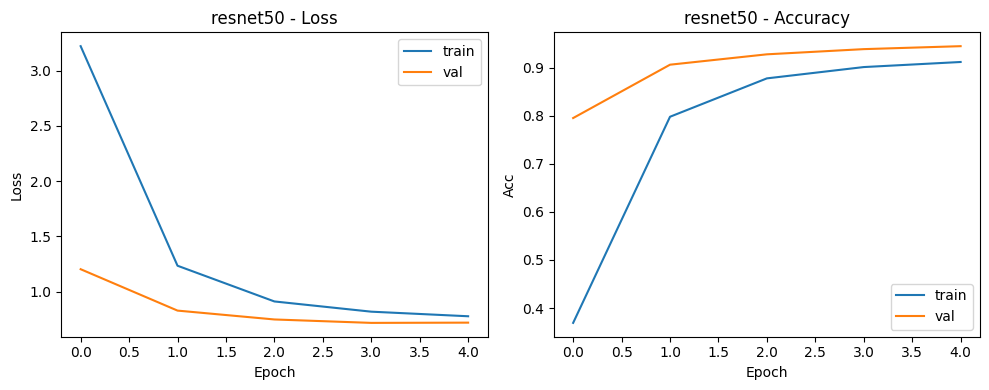

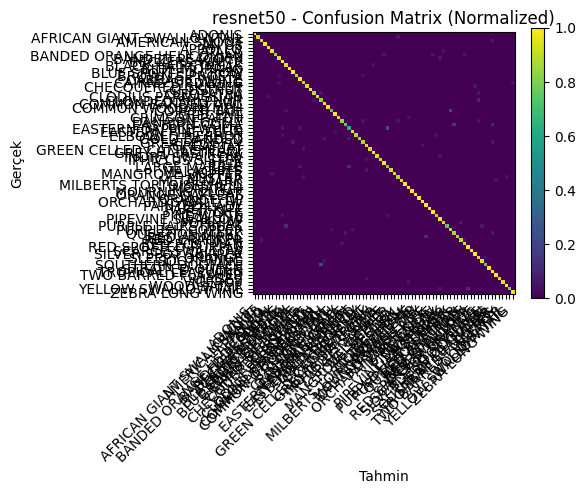


=== Test Report ===
                           precision    recall  f1-score   support

                   ADONIS     0.9444    1.0000    0.9714        17
AFRICAN GIANT SWALLOWTAIL     1.0000    0.9333    0.9655        15
           AMERICAN SNOOT     0.9333    0.9333    0.9333        15
                    AN 88     1.0000    1.0000    1.0000        17
                  APPOLLO     0.9474    1.0000    0.9730        18
                    ATALA     0.9500    0.9500    0.9500        20
 BANDED ORANGE HELICONIAN     1.0000    0.8421    0.9143        19
           BANDED PEACOCK     0.8889    0.9412    0.9143        17
            BECKERS WHITE     0.8421    1.0000    0.9143        16
         BLACK HAIRSTREAK     0.8421    0.9412    0.8889        17
              BLUE MORPHO     1.0000    1.0000    1.0000        15
        BLUE SPOTTED CROW     0.9444    1.0000    0.9714        17
           BROWN SIPROETA     1.0000    0.9000    0.9474        20
            CABBAGE WHITE     0.9000    

100%|██████████| 30.8M/30.8M [00:00<00:00, 211MB/s]



=== Training densenet121 ===


/tmp/ipython-input-3123343829.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 01/5 | train 3.3600/0.3585 | val 1.7760/0.7427 | 70.8s
Epoch 02/5 | train 2.0222/0.7210 | val 1.2906/0.8536 | 48.9s
Epoch 03/5 | train 1.6461/0.7892 | val 1.1150/0.8829 | 46.8s
Epoch 04/5 | train 1.4972/0.8160 | val 1.0817/0.8937 | 48.3s
Epoch 05/5 | train 1.2924/0.8224 | val 0.8672/0.8998 | 48.4s


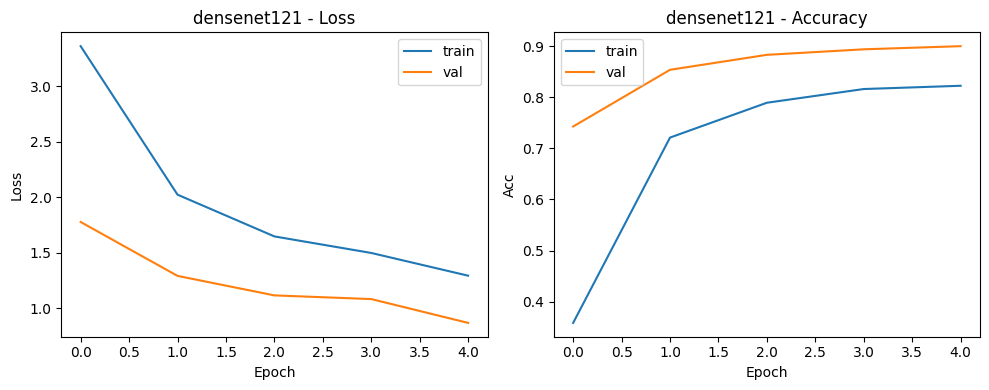

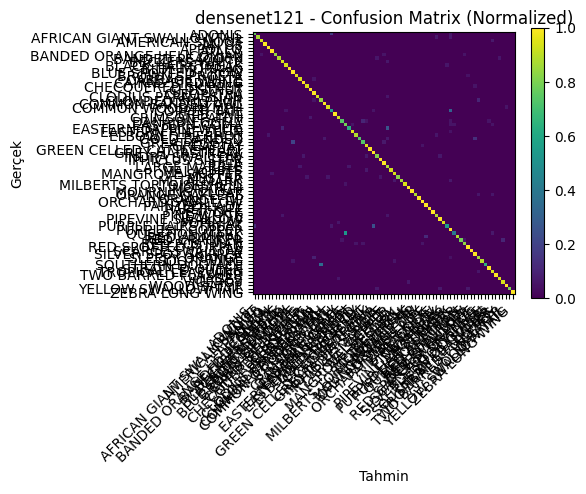


=== Test Report ===
                           precision    recall  f1-score   support

                   ADONIS     0.8667    0.7647    0.8125        17
AFRICAN GIANT SWALLOWTAIL     1.0000    0.8667    0.9286        15
           AMERICAN SNOOT     0.9333    0.9333    0.9333        15
                    AN 88     1.0000    1.0000    1.0000        17
                  APPOLLO     0.9474    1.0000    0.9730        18
                    ATALA     0.9524    1.0000    0.9756        20
 BANDED ORANGE HELICONIAN     1.0000    0.8421    0.9143        19
           BANDED PEACOCK     1.0000    0.8824    0.9375        17
            BECKERS WHITE     0.8333    0.9375    0.8824        16
         BLACK HAIRSTREAK     0.9412    0.9412    0.9412        17
              BLUE MORPHO     1.0000    1.0000    1.0000        15
        BLUE SPOTTED CROW     0.8095    1.0000    0.8947        17
           BROWN SIPROETA     1.0000    0.9500    0.9744        20
            CABBAGE WHITE     0.9444    

100%|██████████| 109M/109M [00:00<00:00, 187MB/s] 



=== Training convnext_tiny ===


/tmp/ipython-input-3123343829.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 01/5 | train 2.8744/0.4709 | val 1.0994/0.8613 | 91.9s
Epoch 02/5 | train 1.0566/0.8789 | val 0.7523/0.9183 | 46.4s
Epoch 03/5 | train 0.7962/0.9233 | val 0.6876/0.9414 | 44.6s
Epoch 04/5 | train 0.7113/0.9398 | val 0.6669/0.9430 | 44.6s
Epoch 05/5 | train 0.6834/0.9477 | val 0.6639/0.9445 | 45.0s


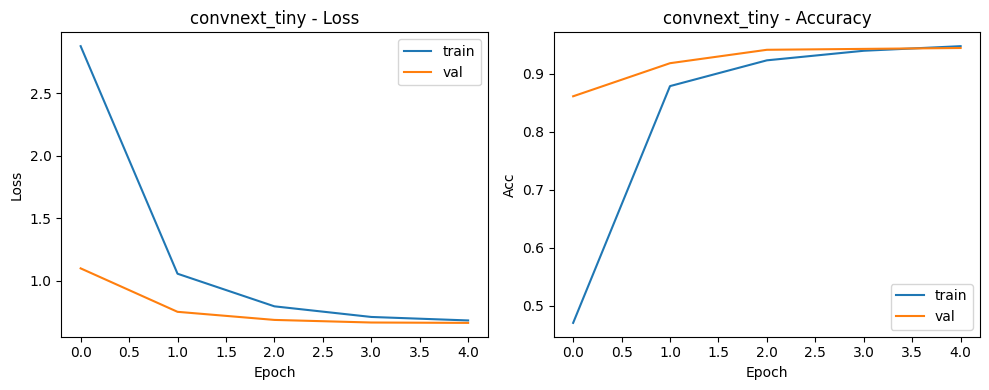

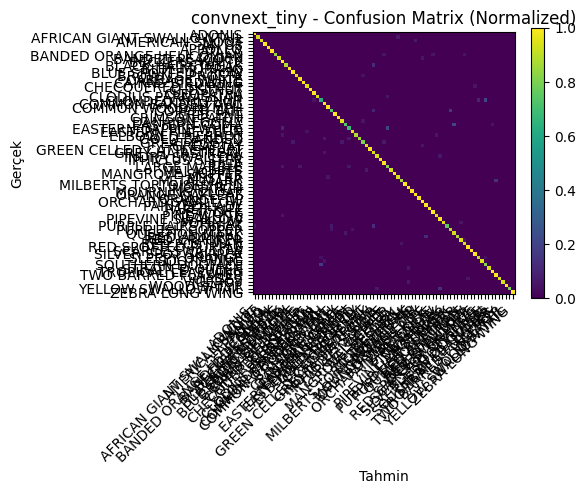


=== Test Report ===
                           precision    recall  f1-score   support

                   ADONIS     0.9444    1.0000    0.9714        17
AFRICAN GIANT SWALLOWTAIL     1.0000    0.9333    0.9655        15
           AMERICAN SNOOT     1.0000    0.9333    0.9655        15
                    AN 88     1.0000    1.0000    1.0000        17
                  APPOLLO     1.0000    1.0000    1.0000        18
                    ATALA     1.0000    1.0000    1.0000        20
 BANDED ORANGE HELICONIAN     1.0000    0.8421    0.9143        19
           BANDED PEACOCK     1.0000    0.9412    0.9697        17
            BECKERS WHITE     0.7619    1.0000    0.8649        16
         BLACK HAIRSTREAK     1.0000    0.8824    0.9375        17
              BLUE MORPHO     1.0000    1.0000    1.0000        15
        BLUE SPOTTED CROW     0.9444    1.0000    0.9714        17
           BROWN SIPROETA     1.0000    0.9500    0.9744        20
            CABBAGE WHITE     0.9474    

100%|██████████| 108M/108M [00:00<00:00, 191MB/s] 



=== Training swin_t ===


/tmp/ipython-input-3123343829.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 01/5 | train 2.4142/0.4981 | val 0.8640/0.8644 | 50.0s
Epoch 02/5 | train 1.0195/0.8459 | val 0.7821/0.9014 | 47.8s
Epoch 03/5 | train 0.8373/0.9033 | val 0.7090/0.9368 | 48.6s
Epoch 04/5 | train 0.7800/0.9195 | val 0.6917/0.9430 | 47.8s
Epoch 05/5 | train 0.7433/0.9330 | val 0.6895/0.9461 | 47.6s


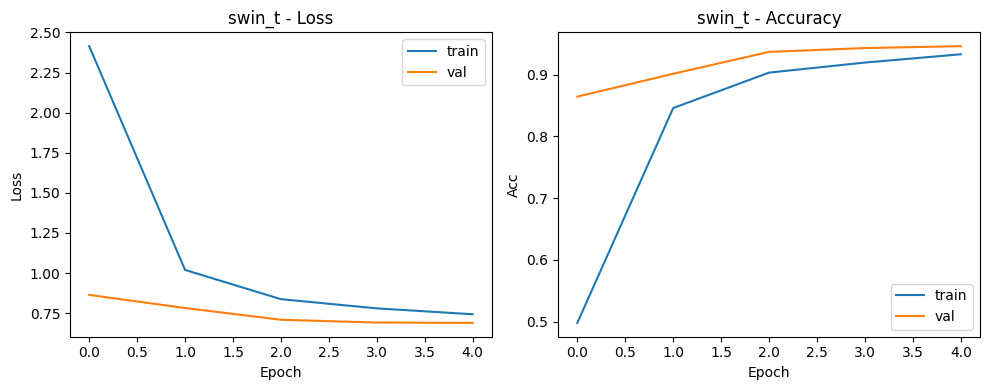

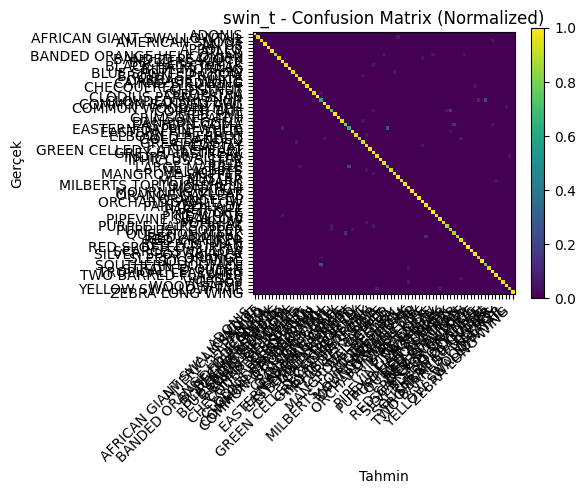


=== Test Report ===
                           precision    recall  f1-score   support

                   ADONIS     1.0000    1.0000    1.0000        17
AFRICAN GIANT SWALLOWTAIL     1.0000    0.9333    0.9655        15
           AMERICAN SNOOT     1.0000    0.9333    0.9655        15
                    AN 88     1.0000    1.0000    1.0000        17
                  APPOLLO     1.0000    1.0000    1.0000        18
                    ATALA     1.0000    1.0000    1.0000        20
 BANDED ORANGE HELICONIAN     1.0000    0.8421    0.9143        19
           BANDED PEACOCK     1.0000    0.9412    0.9697        17
            BECKERS WHITE     0.8421    1.0000    0.9143        16
         BLACK HAIRSTREAK     1.0000    0.9412    0.9697        17
              BLUE MORPHO     1.0000    1.0000    1.0000        15
        BLUE SPOTTED CROW     1.0000    0.9412    0.9697        17
           BROWN SIPROETA     0.9500    0.9500    0.9500        20
            CABBAGE WHITE     0.9474    

In [17]:
results = []
for mname in MODEL_NAMES:
    results.append(train_one_model(mname))


In [18]:
# results: [{name, best_val_acc, test_acc, ...}, ...]

# Validation accuracy'ye göre sırala
sorted_results = sorted(
    results,
    key=lambda x: x["best_val_acc"],
    reverse=True
)

top2 = sorted_results[:2]

print("=== EN IYI 2 MODEL ===")
for r in top2:
    print(
        f"{r['name']} | "
        f"Best Val Acc: {r['best_val_acc']:.4f} | "
        f"Test Acc: {r['test_acc']:.4f}"
    )


=== EN IYI 2 MODEL ===
swin_t | Best Val Acc: 0.9461 | Test Acc: 0.9447
resnet50 | Best Val Acc: 0.9445 | Test Acc: 0.9339


In [19]:
sorted_results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)
top2 = sorted_results[:2]

print("=== EN IYI 2 MODEL ===")
for r in top2:
    print(f"{r['name']} | Best Val Acc: {r['best_val_acc']:.4f} | Test Acc: {r['test_acc']:.4f}")


=== EN IYI 2 MODEL ===
swin_t | Best Val Acc: 0.9461 | Test Acc: 0.9447
resnet50 | Best Val Acc: 0.9445 | Test Acc: 0.9339


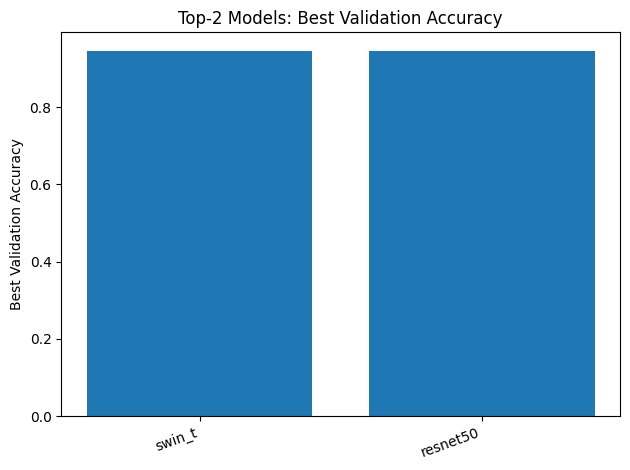

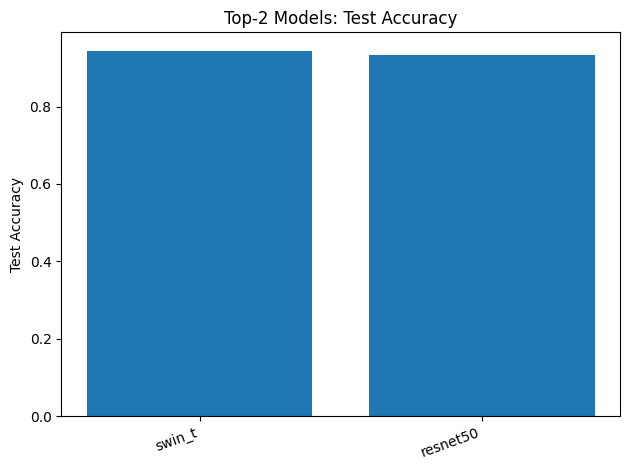

Kaydedildi: /content/outputs/top2_best_val_acc_bar.png /content/outputs/top2_test_acc_bar.png


In [20]:
import os
import matplotlib.pyplot as plt

# results -> [{'name':..., 'history':..., 'test_acc':..., 'best_val_acc':...}, ...]

# En iyi 2 modeli val'e göre seç
sorted_results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)
top2 = sorted_results[:2]

names = [r["name"] for r in top2]
val_accs = [r["best_val_acc"] for r in top2]
test_accs = [r["test_acc"] for r in top2]

# Val accuracy bar
plt.figure()
plt.bar(names, val_accs)
plt.ylabel("Best Validation Accuracy")
plt.title("Top-2 Models: Best Validation Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top2_best_val_acc_bar.png"), dpi=150)
plt.show()

# Test accuracy bar
plt.figure()
plt.bar(names, test_accs)
plt.ylabel("Test Accuracy")
plt.title("Top-2 Models: Test Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top2_test_acc_bar.png"), dpi=150)
plt.show()

print("Kaydedildi:",
      os.path.join(OUTPUT_DIR, "top2_best_val_acc_bar.png"),
      os.path.join(OUTPUT_DIR, "top2_test_acc_bar.png"))


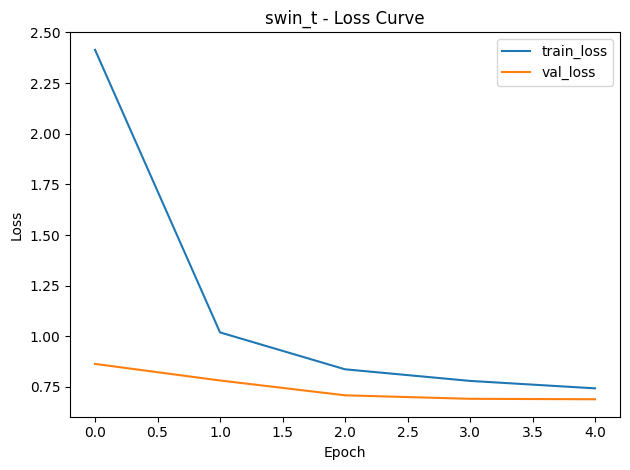

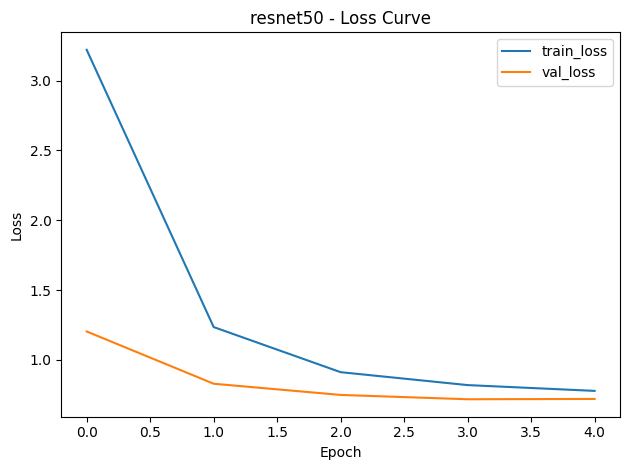

Loss grafikleri kaydedildi.


In [21]:
for r in top2:
    name = r["name"]
    h = r["history"]

    plt.figure()
    plt.plot(h["train_loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name} - Loss Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"TOP2_{name}_loss.png"), dpi=150)
    plt.show()

print("Loss grafikleri kaydedildi.")


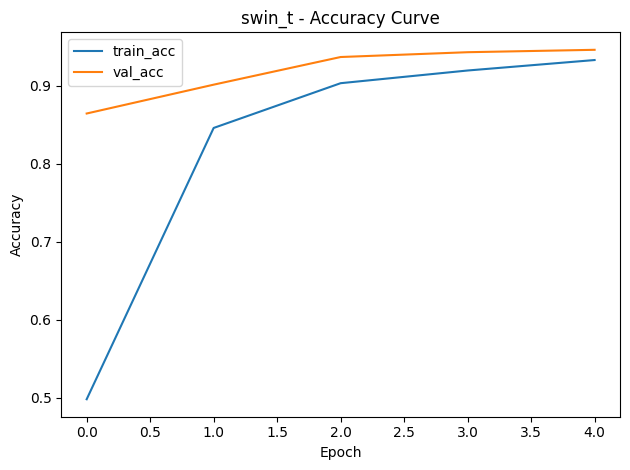

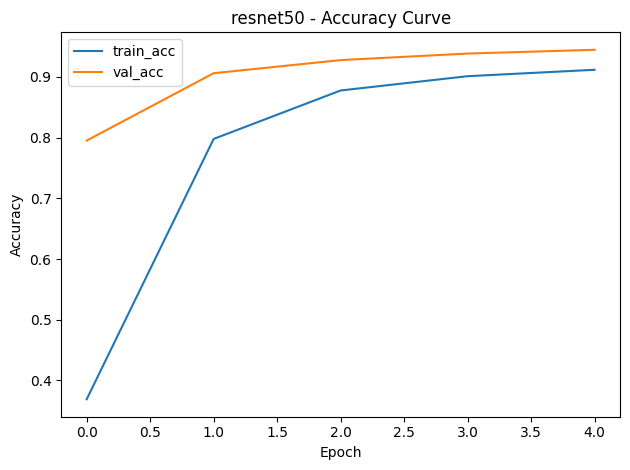

Accuracy grafikleri kaydedildi.


In [22]:
for r in top2:
    name = r["name"]
    h = r["history"]

    plt.figure()
    plt.plot(h["train_acc"], label="train_acc")
    plt.plot(h["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{name} - Accuracy Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"TOP2_{name}_acc.png"), dpi=150)
    plt.show()

print("Accuracy grafikleri kaydedildi.")


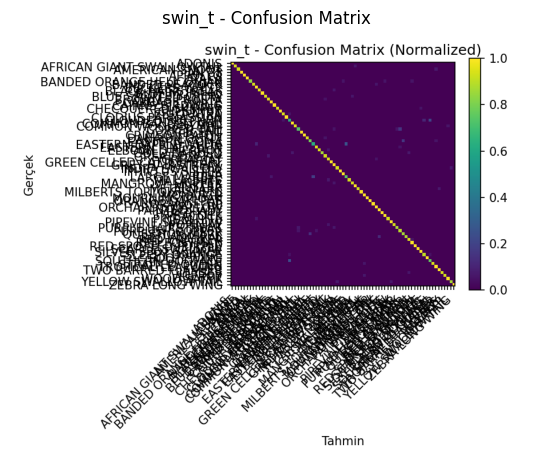

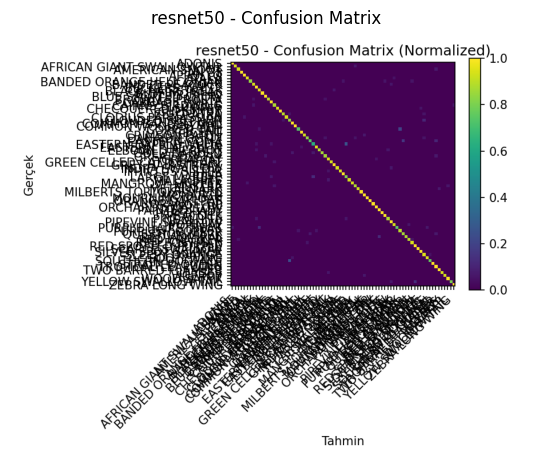

In [23]:
from PIL import Image
import matplotlib.pyplot as plt
import os

for name in names:
    cm_path = os.path.join(OUTPUT_DIR, f"{name}_cm.png")
    if os.path.exists(cm_path):
        img = Image.open(cm_path)
        plt.figure()
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{name} - Confusion Matrix")
        plt.tight_layout()
        plt.show()
    else:
        print("Bulunamadı:", cm_path)


In [24]:
!ls -lah {OUTPUT_DIR}


total 332M
drwxr-xr-x 2 root root 4.0K Jan  1 23:04 .
drwxr-xr-x 1 root root 4.0K Jan  1 22:46 ..
-rw-r--r-- 1 root root 107M Jan  1 23:00 best_convnext_tiny.pth
-rw-r--r-- 1 root root  28M Jan  1 22:55 best_densenet121.pth
-rw-r--r-- 1 root root  91M Jan  1 22:50 best_resnet50.pth
-rw-r--r-- 1 root root 106M Jan  1 23:04 best_swin_t.pth
-rw-r--r-- 1 root root 297K Jan  1 23:00 convnext_tiny_cm.png
-rw-r--r-- 1 root root  57K Jan  1 23:00 convnext_tiny_curves.png
-rw-r--r-- 1 root root 5.3K Jan  1 23:00 convnext_tiny_report.txt
-rw-r--r-- 1 root root 297K Jan  1 22:55 densenet121_cm.png
-rw-r--r-- 1 root root  63K Jan  1 22:55 densenet121_curves.png
-rw-r--r-- 1 root root 5.3K Jan  1 22:55 densenet121_report.txt
-rw-r--r-- 1 root root 297K Jan  1 22:50 resnet50_cm.png
-rw-r--r-- 1 root root  60K Jan  1 22:50 resnet50_curves.png
-rw-r--r-- 1 root root 5.3K Jan  1 22:50 resnet50_report.txt
-rw-r--r-- 1 root root 296K Jan  1 23:04 swin_t_cm.png
-rw-r--r-- 1 root root  60K Jan  1 23:04 swi

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

def evaluate_predictions(y_true, y_pred, class_names, title=""):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n=== {title} ===")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}   (75 sınıfta en adil metrik)")
    print(f"Weighted F1  : {weighted_f1:.4f}")

    # kısa rapor (çok uzamasın diye macro avg / weighted avg odak)
    rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    print("\nMacro avg:", {k: round(rep["macro avg"][k], 4) for k in ["precision","recall","f1-score"]})
    print("Weighted avg:", {k: round(rep["weighted avg"][k], 4) for k in ["precision","recall","f1-score"]})

    # Confusion Matrix (normalize = true) -> hangi sınıflar çok karışıyor
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure()
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(f"Confusion Matrix (Normalized) - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

    # En çok karışan sınıflar (en düşük diagonal)
    diag = np.diag(cm_norm)
    worst = np.argsort(diag)[:10]
    print("\nEn çok karışan 10 sınıf (doğru yakalama oranı en düşük):")
    for idx in worst:
        print(f"- {class_names[idx]} | recall≈{diag[idx]:.3f}")

    return {"acc": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1}


In [30]:
import torch
import numpy as np

@torch.no_grad()
def predict_torch(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []

    for xb, yb in dataloader:
        xb = xb.to(device)

        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)

        y_pred.append(preds.cpu().numpy())
        y_true.append(yb.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return y_true, y_pred


In [31]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

def evaluate_predictions(y_true, y_pred, class_names, title=""):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n=== {title} ===")
    print(f"Accuracy   : {acc:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure(figsize=(6,5))
    plt.imshow(cm_norm)
    plt.title(f"Confusion Matrix (Normalized) - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

    return {
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


In [40]:
import os, random, numpy as np, tensorflow as tf

# -------- HIZ MODU --------
FAST_SCAN_EPOCHS = 2      # 6 modeli hızlı tarama
TOP2_EPOCHS = 6           # sadece top2'yi biraz daha çalıştır
BATCH_SIZE = 64           # GPU uygunsa 64/128 deneyebilirsin
SEED = 42

# -------- ÇIKTI KLASÖRÜ --------
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# -------- SEED (daha stabil sonuçlar) --------
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Ready. Output dir:", OUT_DIR)


Ready. Output dir: outputs


In [41]:
import matplotlib.pyplot as plt

class SaveCurves(tf.keras.callbacks.Callback):
    def __init__(self, name, out_dir="outputs"):
        super().__init__()
        self.name = name
        self.out_dir = out_dir

    def on_train_end(self, logs=None):
        h = self.model.history.history  # Keras History
        # Accuracy
        plt.figure()
        if "accuracy" in h: plt.plot(h["accuracy"], label="train_acc")
        if "val_accuracy" in h: plt.plot(h["val_accuracy"], label="val_acc")
        plt.title(f"{self.name} - Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(self.out_dir, f"{self.name}_acc.png"), dpi=200)
        plt.close()

        # Loss
        plt.figure()
        if "loss" in h: plt.plot(h["loss"], label="train_loss")
        if "val_loss" in h: plt.plot(h["val_loss"], label="val_loss")
        plt.title(f"{self.name} - Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(self.out_dir, f"{self.name}_loss.png"), dpi=200)
        plt.close()


In [45]:
import pandas as pd
import os
import matplotlib.pyplot as plt

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.DataFrame(sorted_results)[["name","best_val_acc","test_acc"]].sort_values("best_val_acc", ascending=False)
print(df)
df.to_csv(os.path.join(OUTPUT_DIR, "results_all.csv"), index=False)

top2 = df["name"].head(2).tolist()
print("TOP2:", top2)


            name  best_val_acc  test_acc
0         swin_t      0.946071  0.944658
1       resnet50      0.944530  0.933897
2  convnext_tiny      0.944530  0.940046
3    densenet121      0.899846  0.908532
TOP2: ['swin_t', 'resnet50']


In [46]:
def save_history_plots(result, out_dir):
    name = result["name"]
    h = result["history"]

    # loss
    plt.figure()
    plt.plot(h["train_loss"], label="train")
    plt.plot(h["val_loss"], label="val")
    plt.title(f"{name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{name}_loss.png"), dpi=200)
    plt.close()

    # acc
    plt.figure()
    plt.plot(h["train_acc"], label="train")
    plt.plot(h["val_acc"], label="val")
    plt.title(f"{name} - Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{name}_acc.png"), dpi=200)
    plt.close()

top2_results = [r for r in sorted_results if r["name"] in top2]
for r in top2_results:
    save_history_plots(r, OUTPUT_DIR)

print("Saved:", [f"{n}_loss.png / {n}_acc.png" for n in top2])


Saved: ['swin_t_loss.png / swin_t_acc.png', 'resnet50_loss.png / resnet50_acc.png']


In [47]:
import pandas as pd

df = pd.DataFrame(sorted_results)[["name","best_val_acc","test_acc"]].copy()
df = df[df["name"].isin(["swin_t","resnet50"])]

df["gap(val-test)"] = df["best_val_acc"] - df["test_acc"]
df = df.sort_values("test_acc", ascending=False)
display(df)


,name,best_val_acc,test_acc,gap(val-test)
0,swin_t,0.946071,0.944658,0.001413
1,resnet50,0.944530,0.933897,0.010633


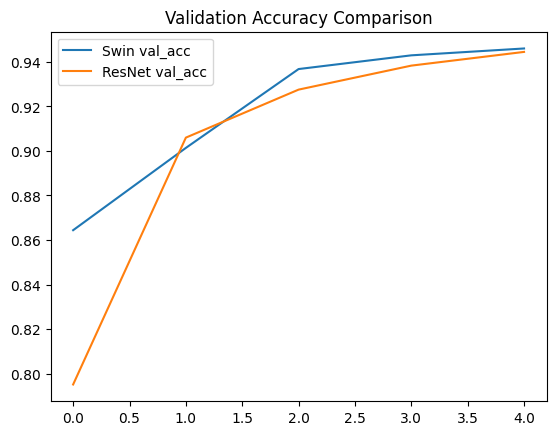

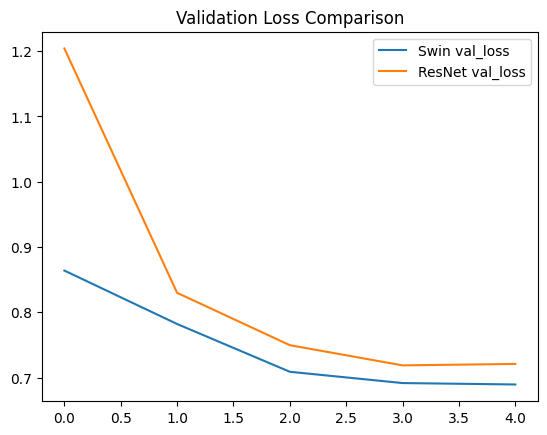

In [48]:
import matplotlib.pyplot as plt

def get_res(name):
    return next(r for r in sorted_results if r["name"] == name)

a = get_res("swin_t")
b = get_res("resnet50")

# Accuracy overlay
plt.figure()
plt.plot(a["history"]["val_acc"], label="Swin val_acc")
plt.plot(b["history"]["val_acc"], label="ResNet val_acc")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

# Loss overlay
plt.figure()
plt.plot(a["history"]["val_loss"], label="Swin val_loss")
plt.plot(b["history"]["val_loss"], label="ResNet val_loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()


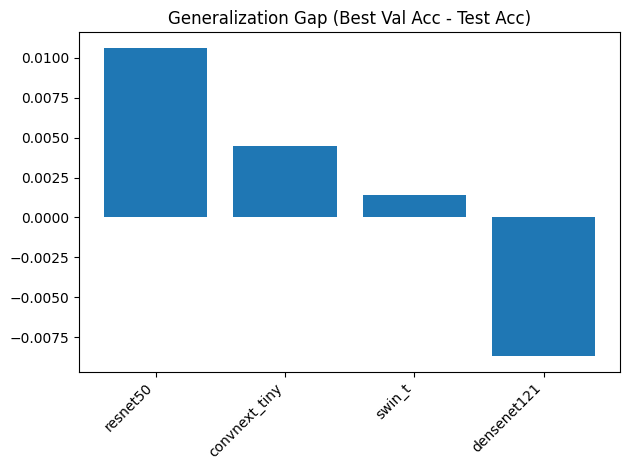

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(sorted_results)[["name","best_val_acc","test_acc"]].copy()
df["gap"] = df["best_val_acc"] - df["test_acc"]
df = df.sort_values("gap", ascending=False)

plt.figure()
plt.bar(df["name"], df["gap"])
plt.title("Generalization Gap (Best Val Acc - Test Acc)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
